In [ ]:
!pip install matplotlib

In [161]:
import math
from matplotlib import pyplot
import random


In [817]:
chunksize = 4*1024
target_level = 1000
fs = 44100
interval = 1.0
tot_t = 1*600

start_level = 800.0
p1 = 150
p2 = 13
a1 = 0.00003
a2 = 0.00000003
k = 0.0001



In [811]:
class PIDAdjuster():
    def __init__(self, fs, target_level, chunksize, interval, k_p, k_i, k_d, d_filt_t):
        self.fs = fs
        self.target_level = target_level
        self.chunksize = chunksize
        self.interval = interval
        self.frames_per_interval = interval * fs
        self.accumulated = 0.0
        self.derivative = 0.0
        self.last_err = None
        self.diff_filter_t = d_filt_t
        if self.diff_filter_t < self.interval:
            self.diff_filter_t = self.interval
        self.k_p = k_p
        self.k_i = k_i
        self.k_d = k_d
        self.diff_add_const = self.interval/self.diff_filter_t
        self.history = {"out": [], "P": [], "I": [], "D": []}

    def adjust(self, level):
        err = level - self.target_level
        if self.last_err is None:
            self.last_err = err
        new_derivative = (err - self.last_err) / self.interval
        self.last_err = err 
        rel_diff = err / self.frames_per_interval
        self.accumulated += rel_diff * self.interval
        self.derivative = (1.0 - self.diff_add_const) * self.derivative + self.diff_add_const * new_derivative
        P = self.k_p * rel_diff
        I = self.k_i * self.accumulated 
        D = self.k_d * self.derivative
        rate_diff = P + I + D
        self.history["P"].append(P)
        self.history["I"].append(I)
        self.history["D"].append(D)
        self.history["out"].append(rate_diff)
        if rate_diff > 0.005:
            rate_diff = 0.005
        elif rate_diff < -0.005:
            rate_diff = -0.005
        return 1.0 - rate_diff
    

class RampingPIAdjuster():
    def __init__(self, fs, target_level, chunksize, interval, k_p, k_i, ramp_steps, ramp_trigger_limit):
        self.fs = fs
        self.target_level = target_level
        self.chunksize = chunksize
        self.interval = interval
        self.frames_per_interval = interval * fs
        self.accumulated = 0.0
        self.k_p = k_p
        self.k_i = k_i
        self.history = {"out": [], "P": [], "I": [], "target": []}
        self.ramp_steps = ramp_steps
        self.ramp_trigger_limit = ramp_trigger_limit
        self.ramp_start = None
        self.ramp_step = 0

    def adjust(self, level):
        if self.ramp_step == 0:
            self.ramp_start = level
        if self.ramp_step < self.ramp_steps:
            current_target = self.ramp_start + (self.target_level - self.ramp_start) * self.ramp_step / self.ramp_steps
            self.ramp_step += 1
        else:
            current_target = self.target_level
        err = level - current_target
        rel_diff = err / self.frames_per_interval
        self.accumulated += rel_diff * self.interval
        P = self.k_p * rel_diff
        I = self.k_i * self.accumulated 
        rate_diff = P + I
        self.history["P"].append(P)
        self.history["I"].append(I)
        self.history["out"].append(rate_diff)
        self.history["target"].append(current_target)
        if rate_diff > 0.005:
            rate_diff = 0.005
        elif rate_diff < -0.005:
            rate_diff = -0.005
        return 1.0 - rate_diff

class IncrementalAdjuster():
    def __init__(self, fs, target_level, chunksize, interval):
        self.fs = fs
        self.target_level = target_level
        self.chunksize = chunksize
        self.interval = interval
        self.frames_per_interval = interval * fs
        self.current_adjust = 1.0
        self.prev_diff = 0.0

    def adjust(self, level):
        latency = level * self.current_adjust
        diff = latency - self.target_level
        equality_range = self.target_level / 100.0
        speed_delta = 1e-5
        if diff > 0.0:
            if diff > (self.prev_diff + equality_range):
                # playback latency grows, need to slow down capture more
                self.current_adjust -= 3.0 * speed_delta
            elif abs(diff - self.prev_diff) < equality_range:
                # positive, not changed from last cycle, need to slow down capture a bit
                self.current_adjust -= speed_delta
        elif diff < 0.0:
            if diff < (self.prev_diff - equality_range):
                # playback latency sinks, need to speed up capture more
                self.current_adjust += 3.0 * speed_delta
            elif abs(diff - self.prev_diff) < equality_range:
                # negative, not changed from last cycle, need to speed up capture a bit
                self.current_adjust += speed_delta
        self.prev_diff = diff
        return self.current_adjust


In [818]:
def get_rel_period_at(t):
    if t < tot_t/2:
        return 1.0 + k
    return 1.0 + k + a1*math.sin(2*math.pi*t/p1) + a2*math.sin(2*math.pi*t/p2)

level = start_level
t = 0.0

capture_adjust = 1.0
capture_pos = 0.0

period = 1/fs

chunks_per_interval = round(interval * fs / chunksize)
total_intervals = int(round(tot_t / interval)) 

times = []
levels = []
adjusts = []

# v1.0
#adjuster = PIDAdjuster(fs, target_level, chunksize, interval, 0.5, 0.0, 0.0, 10)

#v2.0 ALSA
#adjuster = IncrementalAdjuster(fs, target_level, chunksize, interval)

# new candidates
#adjuster = PIDAdjuster(fs, target_level, chunksize, interval, 0.25, 0.004, 0.0, 10)

#adjuster = PIDAdjuster(fs, target_level, chunksize, interval, 0.2, 0.004, 0.0, 20)
#adjuster = PIDAdjuster(fs, target_level, chunksize, interval, 0.2, 0.004, 0.00004, 20)

adjuster = RampingPIAdjuster(fs, target_level, chunksize, interval, 0.2, 0.004, 20, 0.1)

for i in range(total_intervals):
    summed = 0
    for c in range(chunks_per_interval):
        t_prev = t
        # loop through each sample, not needed
        #for f in range(chunksize):
        #    rp = period * get_rel_period_at(t)
        #    t += rp
        #    level -= 1

        # assume rate is constant during a chunk
        rp = period * get_rel_period_at(t)
        t += chunksize * rp
        level -= chunksize

        new_capture_frames = (t - t_prev)/(period/capture_adjust) + capture_pos
        rounded_capture_frames = math.floor(new_capture_frames)
        capture_pos = new_capture_frames - rounded_capture_frames
        level += rounded_capture_frames
        measured_level = level + 20*(random.random() - 0.5)
        times.append(t)
        levels.append(measured_level)
        adjusts.append((capture_adjust-1.0)*1000000)
        summed += measured_level
    averaged = summed / chunks_per_interval
    capture_adjust = adjuster.adjust(averaged)
    
    


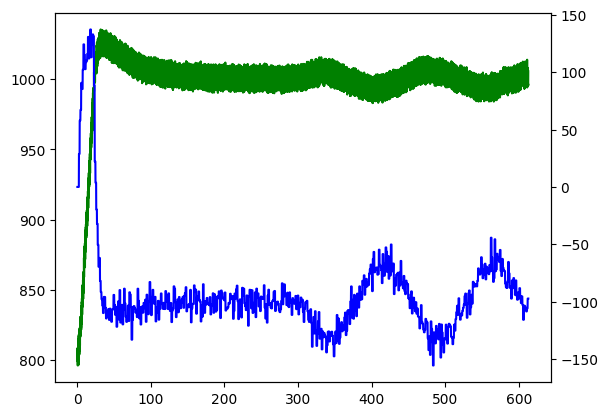

In [819]:

fig, ax1 = pyplot.subplots()

ax2 = ax1.twinx()
ax1.plot(times, levels, 'g-')
ax2.plot(times, adjusts, 'b-')


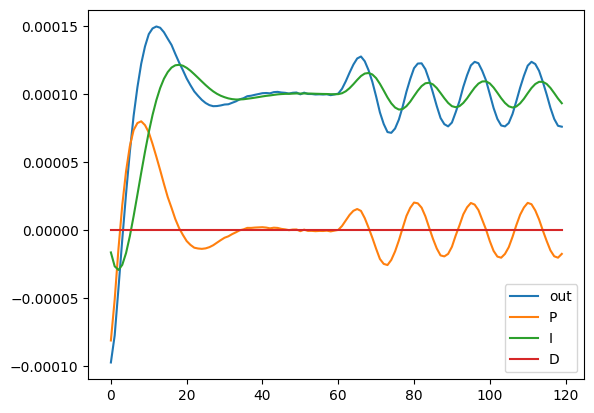

In [810]:
history = adjuster.history
fig = pyplot.figure()
for name, vals in history.items():
    pyplot.plot(vals, label=name)
pyplot.legend()


In [ ]:
# scrap heap

class SimpleAdjuster():
    def __init__(self, fs, target_level, chunksize, interval):
        self.fs = fs
        self.target_level = target_level
        self.chunksize = chunksize
        self.interval = interval
        self.frames_per_interval = interval * fs

    def adjust(self, level):
        diff = level - self.target_level
        rel_diff = diff  / self.fs
        rate_diff = 0.5 * rel_diff / interval
        if rate_diff > 0.005:
            rate_diff = 0.005
        elif rate_diff < -0.005:
            rate_diff = -0.005
        return 1.0 - rate_diff
    
class IntegratingAdjuster():
    def __init__(self, fs, target_level, chunksize, interval):
        self.fs = fs
        self.target_level = target_level
        self.chunksize = chunksize
        self.interval = interval
        self.frames_per_interval = interval * fs
        self.acc_diff = 0.0

    def adjust(self, level):
        diff = level - self.target_level
        rel_diff = diff / self.frames_per_interval
        self.acc_diff = 1.0*self.acc_diff + rel_diff * self.interval
        
        rate_diff = 0.25*rel_diff + 0.004*self.acc_diff
        if rate_diff > 0.005:
            rate_diff = 0.005
        elif rate_diff < -0.005:
            rate_diff = -0.005
        return 1.0 - rate_diff